# March Madness Prediction & Bracket Simulation

End-to-end pipeline:
1. Load data (Kaggle MMLM CSVs or Barttorvik)
2. Build pairwise matchup feature store
3. Train LightGBM + XGBoost ensemble with expanding window CV
4. Historical tournament backtesting (log loss, upset calibration)
5. 2026 bracket simulation with Monte Carlo

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

from data.cbb_data_loader import CBBDataManager, KaggleMMLMLoader
from data.cbb_feature_engineering import (
    build_full_feature_store, build_team_features, build_prediction_matchups
)
from models.cbb_train_matchup_model import CBBMatchupTrainer, evaluate_predictions
from models.cbb_bracket_simulator import (
    run_bracket_simulation, BracketSimulator, build_bracket_from_teams
)

sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

CACHE_DIR = os.path.join(os.getcwd(), 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)
print('Ready')

Ready


## 1. Data Loading

Load from Kaggle MMLM CSVs if available, otherwise use Barttorvik.

Place Kaggle files in `data-core/data/cbb/`:
- `MRegularSeasonDetailedResults.csv`
- `MNCAATourneyDetailedResults.csv` (or Compact)
- `MNCAATourneySeeds.csv`
- `MTeams.csv`

In [2]:
dm = CBBDataManager()
team_stats, tourney, seeds = dm.build_historical_dataset(min_season=2010)

print(f'Team stats: {team_stats.shape if not team_stats.empty else "empty"}')
print(f'Tourney results: {tourney.shape if not tourney.empty else "empty"}')
print(f'Seeds: {seeds.shape if not seeds.empty else "empty"}')

if not team_stats.empty:
    display(team_stats.head())

Building historical CBB dataset...

1. Computing season-level team stats from game data...
  Season 2010: 347 teams
  Season 2011: 345 teams
  Season 2012: 345 teams
  Season 2013: 347 teams
  Season 2014: 351 teams
  Season 2015: 351 teams
  Season 2016: 351 teams
  Season 2017: 351 teams
  Season 2018: 351 teams
  Season 2019: 353 teams
  Season 2021: 347 teams
  Season 2022: 358 teams
  Season 2023: 363 teams
  Season 2024: 362 teams
  Season 2025: 364 teams
  Season 2026: 365 teams

2. Loading tournament results...

3. Loading tournament seeds...

4. Loading team names...

Saved team stats to /home/dmboynton/projects/sports-edge/data-core/notebooks/../src/data/../../notebooks/cache/cbb_team_stats.csv: 5651 rows
Team stats: (5651, 24)
Tourney results: (1001, 34)
Seeds: (1017, 5)


,Season,TeamID,games,wins,losses,win_pct,points_per_game,points_allowed_per_game,off_eff,def_eff,net_eff,tempo,off_efg,off_to_rate,off_or_rate,off_ftr,def_efg,def_to_rate,def_or_rate,def_ftr,ast_per_game,stl_per_game,blk_per_game,TeamName
0,2010,1143,33,23,10,0.696970,77.969697,68.393939,113.421717,100.285483,13.136234,68.471212,0.533696,0.174563,0.352230,0.266459,0.483209,0.189729,0.307093,0.236674,14.454545,5.666667,2.484848,California
1,2010,1293,32,28,4,0.875000,76.093750,61.031250,112.862109,89.767308,23.094801,67.705078,0.554751,0.215064,0.390641,0.301275,0.438642,0.243149,0.333333,0.237443,15.187500,9.281250,5.406250,Murray St
2,2010,1314,32,16,16,0.500000,75.187500,72.312500,102.499654,98.783351,3.716303,73.278516,0.481763,0.210026,0.395748,0.255319,0.470321,0.188687,0.331518,0.167066,15.625000,6.812500,5.812500,North Carolina
3,2010,1198,31,6,25,0.193548,67.354839,77.000000,97.076771,111.458722,-14.381951,69.233468,0.461602,0.192480,0.307953,0.222161,0.560058,0.213392,0.349336,0.271720,12.225806,8.064516,1.806452,Florida Intl
4,2010,1326,34,27,7,0.794118,74.235294,61.205882,113.407620,93.833841,19.573780,65.343382,0.563928,0.172987,0.295694,0.245375,0.473785,0.217788,0.284111,0.188968,14.705882,7.147059,4.088235,Ohio St


## 2. EDA — Team Stats Distribution

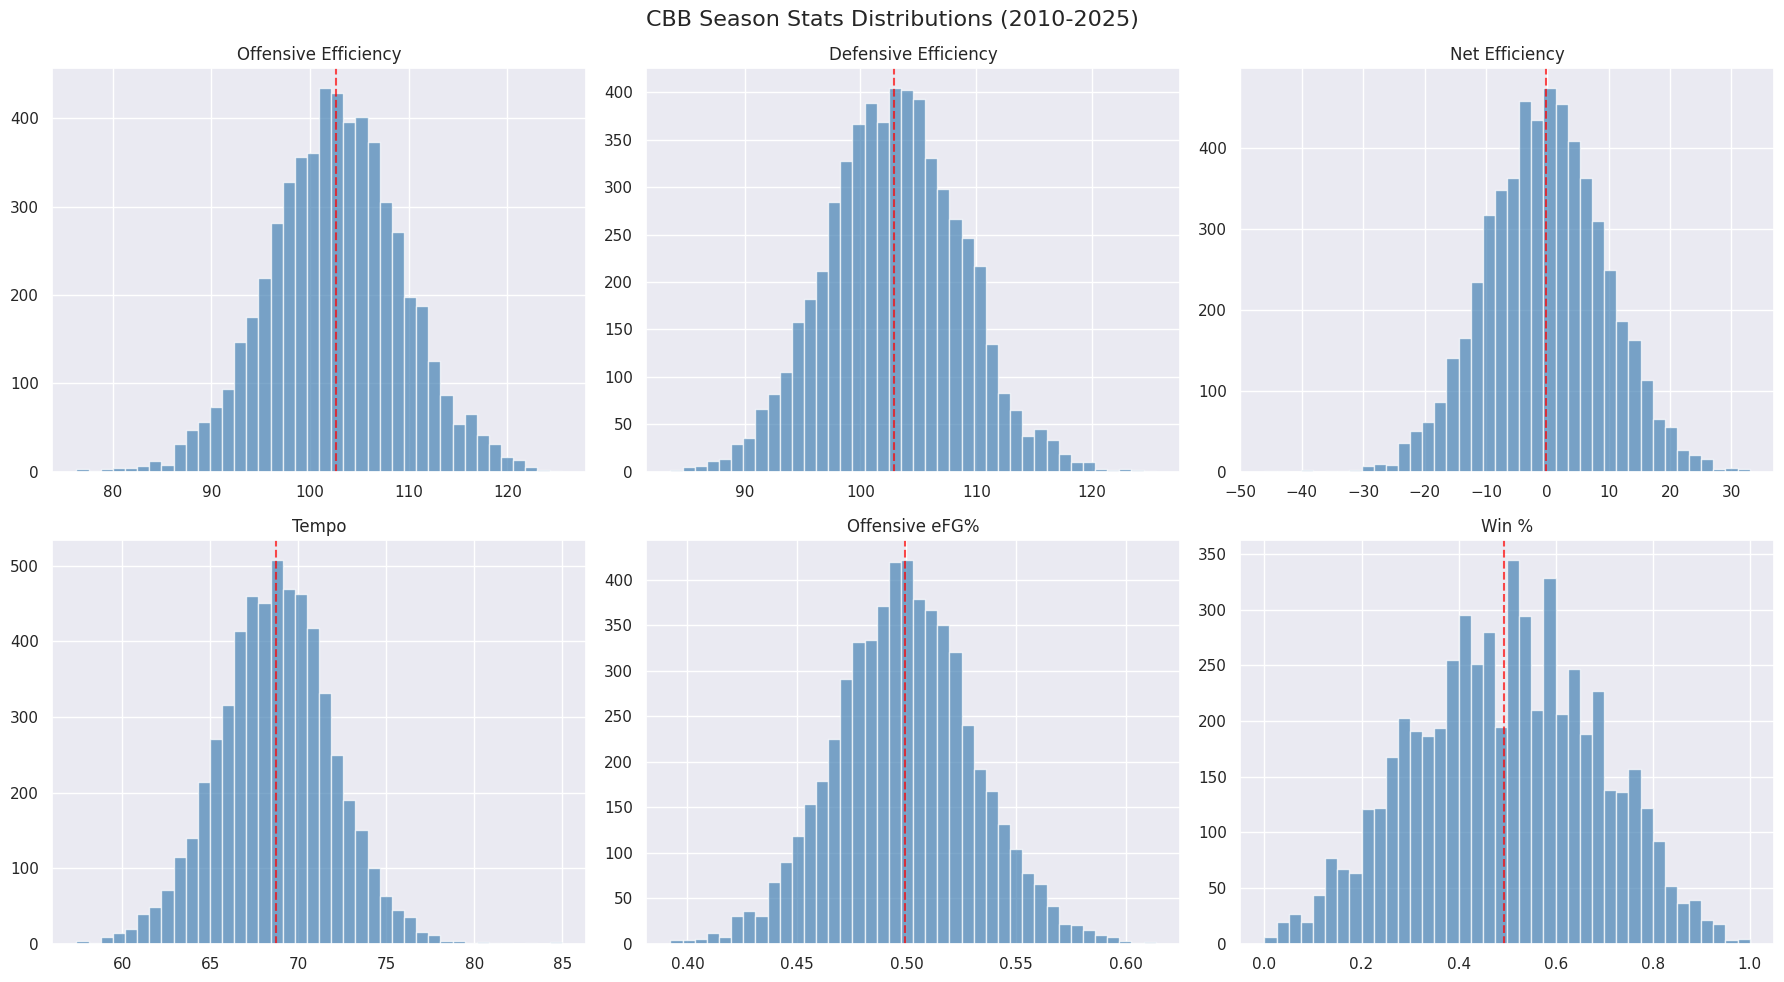

In [3]:
if not team_stats.empty:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('CBB Season Stats Distributions (2010-2025)', fontsize=16)
    
    for ax, col, title in zip(
        axes.flat,
        ['off_eff', 'def_eff', 'net_eff', 'tempo', 'off_efg', 'win_pct'],
        ['Offensive Efficiency', 'Defensive Efficiency', 'Net Efficiency',
         'Tempo', 'Offensive eFG%', 'Win %']
    ):
        if col in team_stats.columns:
            team_stats[col].hist(ax=ax, bins=40, alpha=0.7, color='steelblue')
            ax.set_title(title)
            ax.axvline(team_stats[col].mean(), color='red', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
else:
    print('No team stats data available. Place Kaggle CSVs in data-core/data/cbb/')

## 3. Build Matchup Feature Store

In [4]:
feature_store_path = os.path.join(CACHE_DIR, 'cbb_matchup_feature_store.csv')

if os.path.exists(feature_store_path):
    print(f'Loading cached feature store from {feature_store_path}')
    feature_store = pd.read_csv(feature_store_path)
elif not team_stats.empty and not tourney.empty:
    results_df = dm.kaggle.load_regular_season()
    feature_store = build_full_feature_store(
        team_stats, results_df, tourney, seeds,
        min_season=2010, max_season=2025
    )
else:
    print('No data available to build feature store.')
    feature_store = pd.DataFrame()

if not feature_store.empty:
    print(f'Feature store shape: {feature_store.shape}')
    print(f'Seasons: {sorted(feature_store["Season"].unique())}')
    print(f'Target distribution: {feature_store["team_a_wins"].value_counts().to_dict()}')
    display(feature_store.head())

Loading cached feature store from /home/dmboynton/projects/sports-edge/data-core/notebooks/cache/cbb_matchup_feature_store.csv
Feature store shape: (2002, 52)
Seasons: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Target distribution: {1: 1001, 0: 1001}


,seed_diff,off_eff_diff,def_eff_diff,net_eff_diff,tempo_diff,off_efg_diff,off_to_rate_diff,off_or_rate_diff,off_ftr_diff,def_efg_diff,def_to_rate_diff,def_or_rate_diff,def_ftr_diff,win_pct_diff,sos_diff,tempo_mismatch,recent_win_pct_diff,recent_avg_margin_diff,tourney_exp_diff,avg_seed_hist_diff,a_off_eff,b_off_eff,a_def_eff,b_def_eff,a_net_eff,...,b_tempo,a_off_efg,b_off_efg,a_off_to_rate,b_off_to_rate,a_off_or_rate,b_off_or_rate,a_off_ftr,b_off_ftr,a_def_efg,b_def_efg,a_def_to_rate,b_def_to_rate,a_def_or_rate,b_def_or_rate,a_def_ftr,b_def_ftr,a_win_pct,b_win_pct,a_sos,b_sos,Season,TeamA_ID,TeamB_ID,team_a_wins
0,0.0,0.210458,2.131511,-1.921054,1.612031,0.031096,0.063746,0.019805,0.099806,-0.000334,-0.022220,-0.033537,0.107045,-0.035417,-0.010690,1.612031,0.2,3.4,0.0,0.0,93.158858,92.948401,94.103741,91.972230,-0.944883,...,67.326250,0.450030,0.418934,0.244988,0.181242,0.359821,0.340017,0.325996,0.226190,0.456737,0.457071,0.205483,0.227703,0.263914,0.297450,0.365884,0.258838,0.531250,0.566667,0.448091,0.458781,2010,1115,1457,1
1,0.0,-0.210458,-2.131511,1.921054,-1.612031,-0.031096,-0.063746,-0.019805,-0.099806,0.000334,0.022220,0.033537,-0.107045,0.035417,0.010690,1.612031,-0.2,-3.4,0.0,0.0,92.948401,93.158858,91.972230,94.103741,0.976170,...,68.938281,0.418934,0.450030,0.181242,0.244988,0.340017,0.359821,0.226190,0.325996,0.457071,0.456737,0.227703,0.205483,0.297450,0.263914,0.258838,0.365884,0.566667,0.531250,0.458781,0.448091,2010,1457,1115,0
2,-11.0,0.136955,-3.450216,3.587171,-3.142195,0.002866,0.016523,0.039138,-0.006374,-0.056429,-0.032294,0.025037,-0.054576,0.024194,0.108194,3.142195,0.0,-4.7,0.0,0.0,112.954365,112.817409,98.068810,101.519025,14.885555,...,71.027679,0.546238,0.543372,0.206149,0.189626,0.383367,0.344229,0.273406,0.279780,0.446448,0.502877,0.178264,0.210558,0.329518,0.304481,0.234426,0.289003,0.774194,0.750000,0.579993,0.471800,2010,1124,1358,1
3,11.0,-0.136955,3.450216,-3.587171,3.142195,-0.002866,-0.016523,-0.039138,0.006374,0.056429,0.032294,-0.025037,0.054576,-0.024194,-0.108194,3.142195,0.0,4.7,0.0,0.0,112.817409,112.954365,101.519025,98.068810,11.298384,...,67.885484,0.543372,0.546238,0.189626,0.206149,0.344229,0.383367,0.279780,0.273406,0.502877,0.446448,0.210558,0.178264,0.304481,0.329518,0.289003,0.234426,0.750000,0.774194,0.471800,0.579993,2010,1358,1124,0
4,-7.0,1.725461,1.496981,0.228480,-6.001953,-0.009987,0.006664,0.020279,0.085656,0.021193,-0.014647,-0.032599,-0.039218,0.062500,0.012885,6.001953,0.1,3.4,0.0,0.0,108.313012,106.587550,92.696697,91.199716,15.616315,...,70.739453,0.519925,0.529912,0.191709,0.185045,0.311907,0.291628,0.356787,0.271131,0.463325,0.442132,0.211354,0.226001,0.270531,0.303130,0.247555,0.286773,0.875000,0.812500,0.525635,0.512749,2010,1139,1431,1


## 4. Feature Correlations

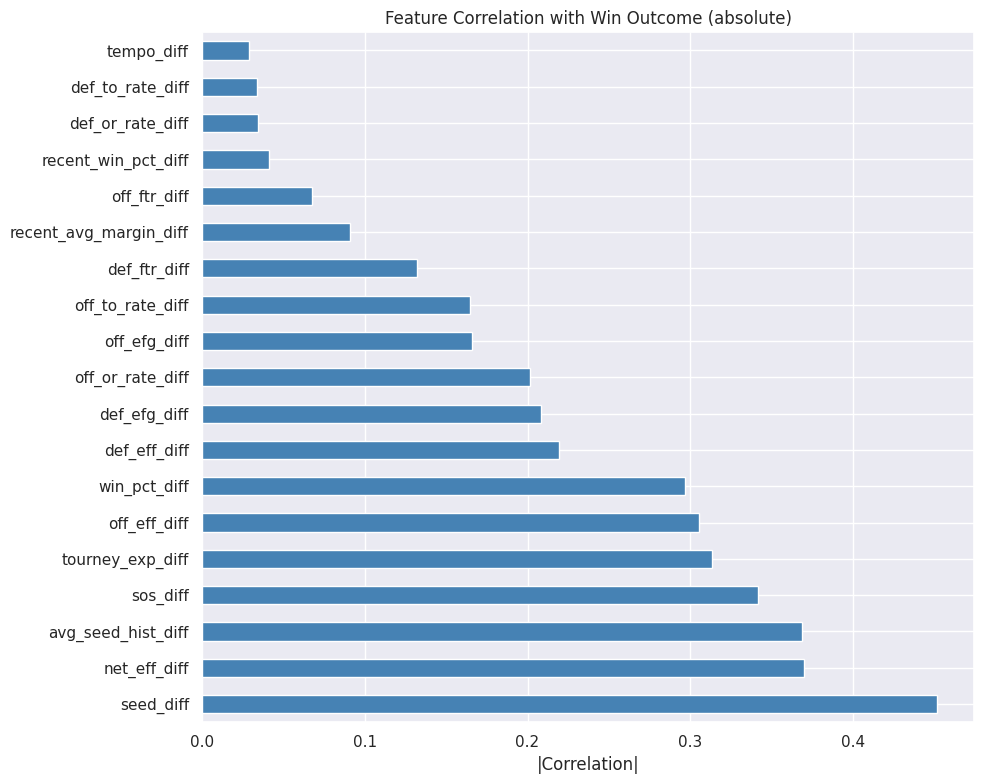

In [5]:
if not feature_store.empty:
    diff_cols = [c for c in feature_store.columns if c.endswith('_diff')]
    corr_with_target = feature_store[diff_cols + ['team_a_wins']].corr()['team_a_wins'].drop('team_a_wins')
    corr_sorted = corr_with_target.abs().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    corr_sorted.head(20).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Feature Correlation with Win Outcome (absolute)')
    ax.set_xlabel('|Correlation|')
    plt.tight_layout()
    plt.show()

## 5. Model Training — Expanding Window CV

In [6]:
if not feature_store.empty:
    trainer = CBBMatchupTrainer()
    cv_results = trainer.expanding_window_cv(
        feature_store,
        train_start=2010,
        val_start=2016,
        val_end=2025
    )
    
    cv_df = pd.DataFrame(cv_results)
    display(cv_df)
else:
    print('No feature store available for training.')

EXPANDING WINDOW CV

Fold: Train 2010-2015 -> Val 2016
  Train: 798 rows, Val: 134 rows

--- LightGBM Classifier ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[59]	valid_0's binary_logloss: 0.635988

  LightGBM:
    Log Loss: 0.6360  |  Brier: 0.2217
    AUC:      0.7022  |  ECE:   0.0665
    Accuracy: 0.6567

--- XGBoost Classifier ---

  XGBoost:
    Log Loss: 0.5943  |  Brier: 0.2012
    AUC:      0.7552  |  ECE:   0.0929
    Accuracy: 0.7537

--- Meta Ensemble (Logistic Regression Stacker) ---
  Meta weights: LGBM=0.500, XGB=1.340
  Intercept: -0.8896

  Meta Ensemble:
    Log Loss: 0.6283  |  Brier: 0.2182
    AUC:      0.7494  |  ECE:   0.1647
    Accuracy: 0.7463

Fold: Train 2010-2016 -> Val 2017
  Train: 932 rows, Val: 134 rows

--- LightGBM Classifier ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[97]	valid_0's binary_logloss: 0.537439

  LightGBM:
    Log Loss: 0.537

,year,lgbm_ll,xgb_ll,meta_ll
0,2016,0.635988,0.594264,0.628305
1,2017,0.537439,0.516986,0.527485
2,2018,0.599258,0.586442,0.606257
3,2019,0.541416,0.530348,0.566776
4,2021,0.590535,0.606015,0.616307
5,2022,0.623637,0.622114,0.634198
6,2023,0.636033,0.609577,0.627042
7,2024,0.549408,0.561956,0.567696
8,2025,0.475713,0.455743,0.501388


## 6. CV Results Visualization

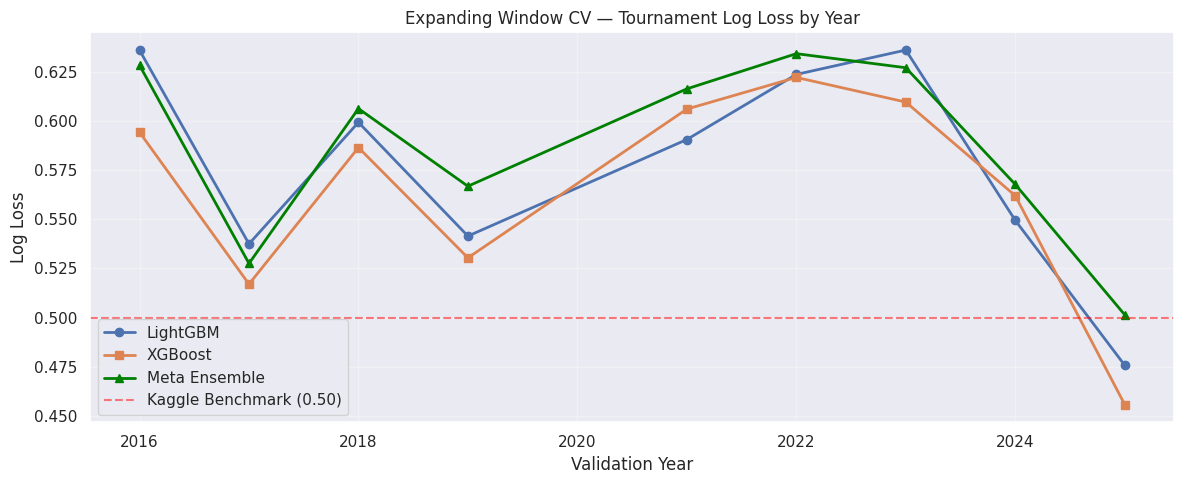

In [7]:
if not feature_store.empty and 'cv_df' in dir():
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(cv_df['year'], cv_df['lgbm_ll'], 'o-', label='LightGBM', linewidth=2)
    ax.plot(cv_df['year'], cv_df['xgb_ll'], 's-', label='XGBoost', linewidth=2)
    ax.plot(cv_df['year'], cv_df['meta_ll'], '^-', label='Meta Ensemble', linewidth=2, color='green')
    ax.axhline(0.50, color='red', linestyle='--', alpha=0.5, label='Kaggle Benchmark (0.50)')
    ax.set_xlabel('Validation Year')
    ax.set_ylabel('Log Loss')
    ax.set_title('Expanding Window CV — Tournament Log Loss by Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Train Final Production Model

In [8]:
if not feature_store.empty:
    trainer.train_final_model(feature_store)
    print('Final model trained and saved.')


TRAINING FINAL PRODUCTION MODEL
Train: 1701, Hold-out: 301

--- LightGBM Classifier ---
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[135]	valid_0's binary_logloss: 0.559101

  LightGBM:
    Log Loss: 0.5591  |  Brier: 0.1906
    AUC:      0.7796  |  ECE:   0.0442
    Accuracy: 0.7143

--- XGBoost Classifier ---

  XGBoost:
    Log Loss: 0.5628  |  Brier: 0.1911
    AUC:      0.7787  |  ECE:   0.0549
    Accuracy: 0.7043

--- Meta Ensemble (Logistic Regression Stacker) ---
  Meta weights: LGBM=1.448, XGB=1.354
  Intercept: -1.4065

  Meta Ensemble:
    Log Loss: 0.5834  |  Brier: 0.1979
    AUC:      0.7805  |  ECE:   0.0730
    Accuracy: 0.7076

All models saved to /home/dmboynton/projects/sports-edge/data-core/notebooks/../src/models/../../models/saved
Final model trained and saved.


## 8. 2026 Bracket Simulation

Using either trained model predictions or seed-based probabilities.

In [9]:
# Real 2026 NCAA Tournament Bracket with Kaggle TeamIDs
# E=East, W=West, S=South, M=Midwest
BRACKET_2026 = [
    # --- EAST REGION ---
    {"team_id": 1181, "name": "Duke", "seed": 1, "region": "E"},
    {"team_id": 1163, "name": "UConn", "seed": 2, "region": "E"},
    {"team_id": 1277, "name": "Michigan State", "seed": 3, "region": "E"},
    {"team_id": 1242, "name": "Kansas", "seed": 4, "region": "E"},
    {"team_id": 1385, "name": "St. John's", "seed": 5, "region": "E"},
    {"team_id": 1257, "name": "Louisville", "seed": 6, "region": "E"},
    {"team_id": 1417, "name": "UCLA", "seed": 7, "region": "E"},
    {"team_id": 1326, "name": "Ohio State", "seed": 8, "region": "E"},
    {"team_id": 1395, "name": "TCU", "seed": 9, "region": "E"},
    {"team_id": 1416, "name": "UCF", "seed": 10, "region": "E"},
    {"team_id": 1378, "name": "South Florida", "seed": 11, "region": "E"},
    {"team_id": 1320, "name": "Northern Iowa", "seed": 12, "region": "E"},
    {"team_id": 1465, "name": "Cal Baptist", "seed": 13, "region": "E"},
    {"team_id": 1295, "name": "North Dakota State", "seed": 14, "region": "E"},
    {"team_id": 1202, "name": "Furman", "seed": 15, "region": "E"},
    {"team_id": 1373, "name": "Siena", "seed": 16, "region": "E"},

    # --- WEST REGION ---
    {"team_id": 1112, "name": "Arizona", "seed": 1, "region": "W"},
    {"team_id": 1345, "name": "Purdue", "seed": 2, "region": "W"},
    {"team_id": 1211, "name": "Gonzaga", "seed": 3, "region": "W"},
    {"team_id": 1116, "name": "Arkansas", "seed": 4, "region": "W"},
    {"team_id": 1458, "name": "Wisconsin", "seed": 5, "region": "W"},
    {"team_id": 1140, "name": "BYU", "seed": 6, "region": "W"},
    {"team_id": 1274, "name": "Miami FL", "seed": 7, "region": "W"},
    {"team_id": 1437, "name": "Villanova", "seed": 8, "region": "W"},
    {"team_id": 1429, "name": "Utah State", "seed": 9, "region": "W"},
    {"team_id": 1281, "name": "Missouri", "seed": 10, "region": "W"},
    {"team_id": 1301, "name": "NC State", "seed": 11, "region": "W"},
    {"team_id": 1219, "name": "High Point", "seed": 12, "region": "W"},
    {"team_id": 1218, "name": "Hawaii", "seed": 13, "region": "W"},
    {"team_id": 1244, "name": "Kennesaw", "seed": 14, "region": "W"},
    {"team_id": 1474, "name": "Queens NC", "seed": 15, "region": "W"},
    {"team_id": 1254, "name": "LIU Brooklyn", "seed": 16, "region": "W"},

    # --- SOUTH REGION ---
    {"team_id": 1196, "name": "Florida", "seed": 1, "region": "S"},
    {"team_id": 1222, "name": "Houston", "seed": 2, "region": "S"},
    {"team_id": 1228, "name": "Illinois", "seed": 3, "region": "S"},
    {"team_id": 1304, "name": "Nebraska", "seed": 4, "region": "S"},
    {"team_id": 1435, "name": "Vanderbilt", "seed": 5, "region": "S"},
    {"team_id": 1314, "name": "North Carolina", "seed": 6, "region": "S"},
    {"team_id": 1388, "name": "Saint Mary's", "seed": 7, "region": "S"},
    {"team_id": 1155, "name": "Clemson", "seed": 8, "region": "S"},
    {"team_id": 1234, "name": "Iowa", "seed": 9, "region": "S"},
    {"team_id": 1401, "name": "Texas A&M", "seed": 10, "region": "S"},
    {"team_id": 1433, "name": "VCU", "seed": 11, "region": "S"},
    {"team_id": 1270, "name": "McNeese", "seed": 12, "region": "S"},
    {"team_id": 1407, "name": "Troy", "seed": 13, "region": "S"},
    {"team_id": 1335, "name": "Penn", "seed": 14, "region": "S"},
    {"team_id": 1225, "name": "Idaho", "seed": 15, "region": "S"},
    {"team_id": 1250, "name": "Lehigh", "seed": 16, "region": "S"},

    # --- MIDWEST REGION ---
    {"team_id": 1276, "name": "Michigan", "seed": 1, "region": "M"},
    {"team_id": 1235, "name": "Iowa State", "seed": 2, "region": "M"},
    {"team_id": 1438, "name": "Virginia", "seed": 3, "region": "M"},
    {"team_id": 1104, "name": "Alabama", "seed": 4, "region": "M"},
    {"team_id": 1403, "name": "Texas Tech", "seed": 5, "region": "M"},
    {"team_id": 1397, "name": "Tennessee", "seed": 6, "region": "M"},
    {"team_id": 1246, "name": "Kentucky", "seed": 7, "region": "M"},
    {"team_id": 1208, "name": "Georgia", "seed": 8, "region": "M"},
    {"team_id": 1387, "name": "Saint Louis", "seed": 9, "region": "M"},
    {"team_id": 1365, "name": "Santa Clara", "seed": 10, "region": "M"},
    {"team_id": 1374, "name": "SMU", "seed": 11, "region": "M"},
    {"team_id": 1103, "name": "Akron", "seed": 12, "region": "M"},
    {"team_id": 1220, "name": "Hofstra", "seed": 13, "region": "M"},
    {"team_id": 1460, "name": "Wright State", "seed": 14, "region": "M"},
    {"team_id": 1398, "name": "Tennessee State", "seed": 15, "region": "M"},
    {"team_id": 1420, "name": "UMBC", "seed": 16, "region": "M"},
]

print(f'Bracket: {len(BRACKET_2026)} teams, 4 regions')
bracket_ids = [t['team_id'] for t in BRACKET_2026]
print(f'Team IDs: {bracket_ids[:5]}...')

Bracket: 64 teams, 4 regions
Team IDs: [1181, 1163, 1277, 1242, 1385]...


In [10]:
from data.cbb_feature_engineering import (
    build_matchup_row, build_prediction_matchups, build_team_features,
    MATCHUP_FEATURE_COLS
)

n_teams = len(BRACKET_2026)
team_index = {t['team_id']: i for i, t in enumerate(BRACKET_2026)}
bracket_ids = [t['team_id'] for t in BRACKET_2026]

# Build enriched 2026 team features (SOS, recent form, tourney experience)
# Need regular season results for SOS + recent form computation
results_df = dm.kaggle.load_regular_season()

# Build a fake seeds DataFrame for 2026 so build_team_features can use it
bracket_seeds = pd.DataFrame([
    {'Season': 2026, 'TeamID': t['team_id'], 'SeedNum': t['seed'],
     'Region': t['region'], 'Seed': f"{t['region']}{t['seed']:02d}"}
    for t in BRACKET_2026
])
if not seeds.empty:
    all_seeds = pd.concat([seeds, bracket_seeds], ignore_index=True)
else:
    all_seeds = bracket_seeds

team_features_2026 = build_team_features(team_stats, results_df, all_seeds, season=2026)
print(f"2026 team features built: {team_features_2026.shape}")
print(f"  Columns: {list(team_features_2026.columns[:10])}...")

bracket_in_features = set(bracket_ids) & set(team_features_2026['TeamID'].values)
print(f"  Bracket teams with 2026 stats: {len(bracket_in_features)}/{n_teams}")

# Build model-based probability matrix using trained ensemble + real 2026 team stats
use_model = (trainer.lgbm_model is not None and trainer.xgb_model is not None
             and trainer.meta_model is not None and not team_features_2026.empty)

if use_model:
    print("\nBuilding probability matrix from TRAINED MODEL (not just seeds)...")
    matchup_df = build_prediction_matchups(team_features_2026, bracket_ids, season=2026)
    print(f"  Pairwise matchups generated: {len(matchup_df)}")

    missing = set(bracket_ids) - set(team_stats[team_stats['Season'] == 2026]['TeamID'].values)
    if missing:
        print(f"  WARNING: {len(missing)} teams missing from 2026 stats, using seed fallback for their matchups")
        missing_names = [t['name'] for t in BRACKET_2026 if t['team_id'] in missing]
        print(f"    Missing: {missing_names}")

    raw_model_matrix = trainer.build_probability_matrix(matchup_df, bracket_ids)

    # Fill any remaining 0.5 gaps (missing teams) with seed-based fallback
    for i, t1 in enumerate(BRACKET_2026):
        for j, t2 in enumerate(BRACKET_2026):
            if i == j:
                raw_model_matrix[i][j] = 0.0
            elif raw_model_matrix[i][j] == 0.5 and t1['seed'] != t2['seed']:
                seed_diff = t2['seed'] - t1['seed']
                raw_model_matrix[i][j] = 1.0 / (1.0 + np.exp(-0.15 * seed_diff))

    # ------------------------------------------------------------------
    # Calibrate: the meta-ensemble compresses probs toward [0.22, 0.78].
    # Historical NCAA data shows 1v16 should be ~0.99, 8v9 ~0.52, etc.
    # Fix: blend model output with a well-calibrated seed baseline using
    # the model for *relative* team quality and seeds for *magnitude*.
    # ------------------------------------------------------------------
    HIST_SEED_WIN_RATE = {
        (1,16): 0.993, (2,15): 0.94, (3,14): 0.85, (4,13): 0.79,
        (5,12): 0.65,  (6,11): 0.63, (7,10): 0.61, (8,9): 0.52,
    }

    def calibrated_seed_prob(seed_a, seed_b):
        """Interpolated seed-based probability using historical base rates."""
        key = (min(seed_a, seed_b), max(seed_a, seed_b))
        if key in HIST_SEED_WIN_RATE:
            base = HIST_SEED_WIN_RATE[key]
            return base if seed_a < seed_b else 1.0 - base
        diff = seed_b - seed_a
        return 1.0 / (1.0 + np.exp(-0.175 * diff))

    # Build calibrated seed matrix
    seed_matrix = np.full((n_teams, n_teams), 0.5)
    for i, t1 in enumerate(BRACKET_2026):
        for j, t2 in enumerate(BRACKET_2026):
            if i == j:
                seed_matrix[i][j] = 0.0
            else:
                seed_matrix[i][j] = calibrated_seed_prob(t1['seed'], t2['seed'])

    # Adaptive blend: model weight decreases for larger seed gaps where
    # the model's compressed range badly underestimates true odds.
    prob_matrix = np.full((n_teams, n_teams), 0.5)
    for i, t1 in enumerate(BRACKET_2026):
        for j, t2 in enumerate(BRACKET_2026):
            if i == j:
                prob_matrix[i][j] = 0.0
                continue
            gap = abs(t1['seed'] - t2['seed'])
            model_w = max(0.25, 0.70 - 0.03 * gap)
            prob_matrix[i][j] = model_w * raw_model_matrix[i][j] + (1 - model_w) * seed_matrix[i][j]

    np.fill_diagonal(prob_matrix, 0.0)
    prob_matrix = np.clip(prob_matrix, 0.01, 0.99)

    raw_range = (raw_model_matrix[raw_model_matrix > 0].min(), raw_model_matrix.max())
    cal_range = (prob_matrix[prob_matrix > 0].min(), prob_matrix.max())
    print(f"  Raw model range:  [{raw_range[0]:.3f}, {raw_range[1]:.3f}]")
    print(f"  Calibrated range: [{cal_range[0]:.3f}, {cal_range[1]:.3f}]")
    print(f"  Adaptive blend: 70% model (close) -> 25% model (blowouts)")
else:
    print("WARNING: Trained model not available — falling back to seed-only probabilities")
    prob_matrix = np.full((n_teams, n_teams), 0.5)
    for i, t1 in enumerate(BRACKET_2026):
        for j, t2 in enumerate(BRACKET_2026):
            if i == j:
                prob_matrix[i][j] = 0.0
                continue
            seed_diff = t2['seed'] - t1['seed']
            prob_matrix[i][j] = 1.0 / (1.0 + np.exp(-0.15 * seed_diff))

print(f'\nProbability matrix shape: {prob_matrix.shape}')

# Show some example matchups to verify model differentiates beyond seed
duke_idx = team_index[1181]
uconn_idx = team_index[1163]
michigan_idx = team_index[1276]
florida_idx = team_index[1196]
siena_idx = team_index[1373]
stjohns_idx = team_index[1385]

print(f'\nExample probabilities (model-based):')
print(f'  Duke vs Siena (1v16):       {prob_matrix[duke_idx][siena_idx]:.3f}')
print(f'  Duke vs UConn (1v2):        {prob_matrix[duke_idx][uconn_idx]:.3f}')
print(f'  Michigan vs Florida (1v1):  {prob_matrix[michigan_idx][florida_idx]:.3f}')
print(f'  St. John\'s vs UConn (5v2): {prob_matrix[stjohns_idx][uconn_idx]:.3f}')

# Verify model differentiates same-seed teams
one_seeds = [(t['name'], team_index[t['team_id']]) for t in BRACKET_2026 if t['seed'] == 1]
print(f'\n1-seed win prob vs their 16-seed:')
for name, idx in one_seeds:
    sixteen = [t for t in BRACKET_2026 if t['region'] == BRACKET_2026[idx]['region'] and t['seed'] == 16][0]
    s_idx = team_index[sixteen['team_id']]
    print(f'  {name:<15} vs {sixteen["name"]:<20}: {prob_matrix[idx][s_idx]:.3f}')

2026 team features built: (365, 34)
  Columns: ['TeamID', 'Season', 'games', 'wins', 'losses', 'win_pct', 'points_per_game', 'points_allowed_per_game', 'off_eff', 'def_eff']...
  Bracket teams with 2026 stats: 64/64

Building probability matrix from TRAINED MODEL (not just seeds)...
  Pairwise matchups generated: 4032

Probability matrix shape: (64, 64)

Example probabilities (model-based):
  Duke vs Siena (1v16):       0.751
  Duke vs UConn (1v2):        0.645
  Michigan vs Florida (1v1):  0.505
  St. John's vs UConn (5v2): 0.364

1-seed win prob vs their 16-seed:
  Duke            vs Siena               : 0.751
  Arizona         vs LIU Brooklyn        : 0.752
  Florida         vs Lehigh              : 0.720
  Michigan        vs UMBC                : 0.745


### Baseline Simulation (50K runs)

In [11]:
result = run_bracket_simulation(
    prob_matrix=prob_matrix,
    teams=BRACKET_2026,
    team_index=team_index,
    n_sims=50000,
)

table = result['table']
display(table.head(20))

,team,seed,region,R64,R32,S16,E8,F4,Championship,Winner
0,Duke,1,E,1.0,0.75614,0.53314,0.36694,0.24444,0.15410,0.09834
1,Arizona,1,W,1.0,0.75262,0.50406,0.34438,0.22534,0.12990,0.07712
2,Houston,2,S,1.0,0.76666,0.52744,0.34560,0.21272,0.13026,0.07506
3,Florida,1,S,1.0,0.71922,0.46126,0.31438,0.18766,0.11702,0.06356
4,Purdue,2,W,1.0,0.67978,0.46316,0.30768,0.18154,0.10452,0.06154
5,Michigan,1,M,1.0,0.74754,0.52122,0.34148,0.20274,0.10980,0.05670
6,UConn,2,E,1.0,0.76570,0.52068,0.32020,0.17304,0.09752,0.05670
7,Illinois,3,S,1.0,0.69592,0.46126,0.24812,0.15010,0.09194,0.04796
8,Iowa State,2,M,1.0,0.77870,0.49686,0.30962,0.16878,0.08890,0.04662
9,Gonzaga,3,W,1.0,0.75396,0.51978,0.28250,0.15576,0.07728,0.04010


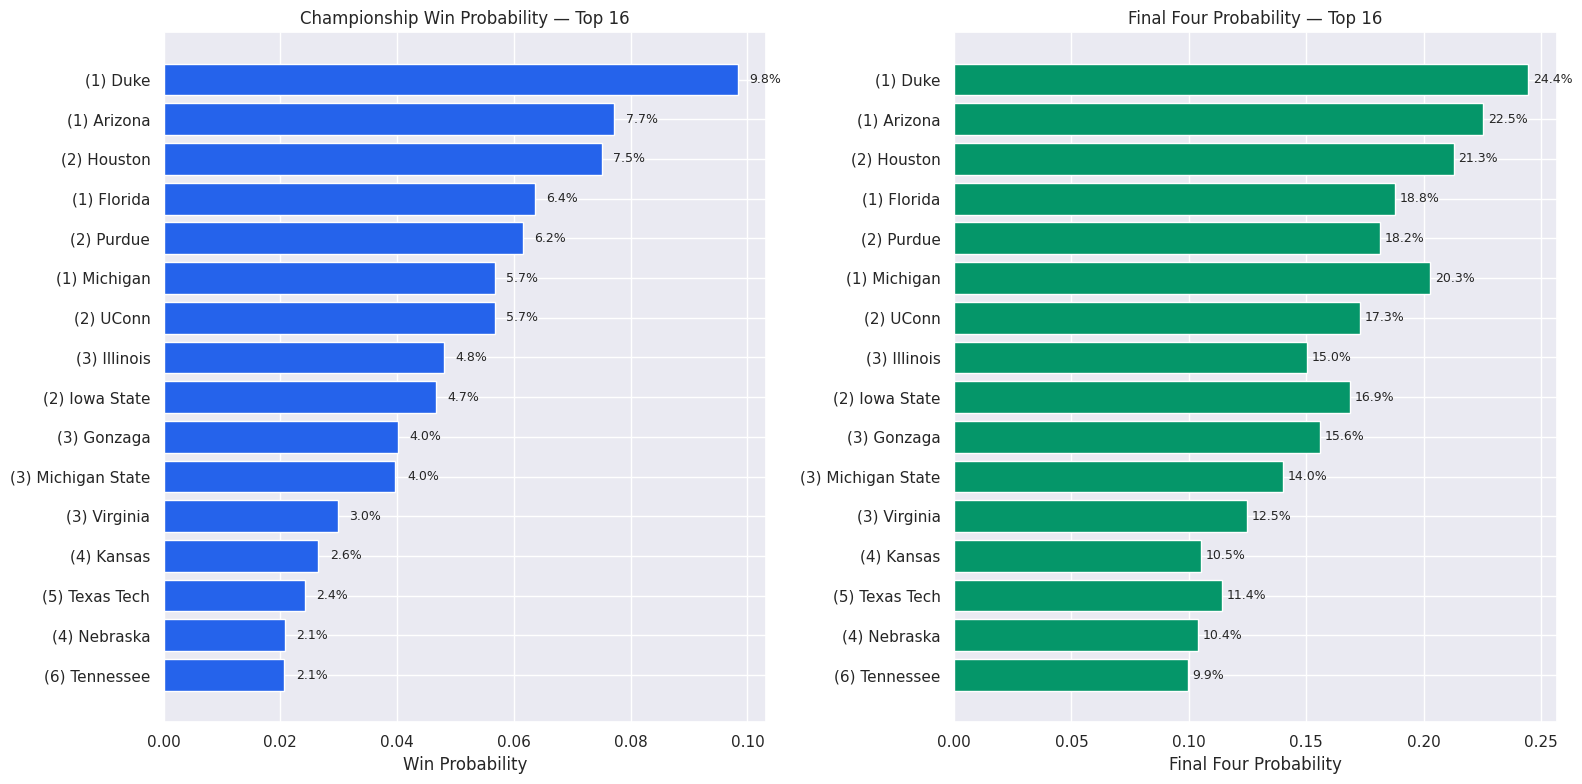

In [12]:
# Visualize top contenders
top_16 = table.head(16).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Win probability
ax = axes[0]
bars = ax.barh(range(len(top_16)), top_16['Winner'].values, color='#2563eb')
ax.set_yticks(range(len(top_16)))
ax.set_yticklabels([f"({r['seed']}) {r['team']}" for _, r in top_16.iterrows()])
ax.set_xlabel('Win Probability')
ax.set_title('Championship Win Probability — Top 16')
ax.invert_yaxis()
for bar, val in zip(bars, top_16['Winner'].values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)

# Final Four probability
ax = axes[1]
bars = ax.barh(range(len(top_16)), top_16['F4'].values, color='#059669')
ax.set_yticks(range(len(top_16)))
ax.set_yticklabels([f"({r['seed']}) {r['team']}" for _, r in top_16.iterrows()])
ax.set_xlabel('Final Four Probability')
ax.set_title('Final Four Probability — Top 16')
ax.invert_yaxis()
for bar, val in zip(bars, top_16['F4'].values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Scenario Analysis

Test what-if scenarios by adding constraints.

In [13]:
# Scenario: Duke loses in Round 1
result_no_duke = run_bracket_simulation(
    prob_matrix=prob_matrix,
    teams=BRACKET_2026,
    team_index=team_index,
    n_sims=50000,
    constraints=[{"team": "Duke", "action": "eliminate", "round": 0}],
)

# Scenario: Houston forced to Final Four
result_houston_ff = run_bracket_simulation(
    prob_matrix=prob_matrix,
    teams=BRACKET_2026,
    team_index=team_index,
    n_sims=50000,
    constraints=[{"team": "Houston", "action": "advance_to", "round": 4}],
)

# Scenario: All 1-seeds lose in R2
result_chaos = run_bracket_simulation(
    prob_matrix=prob_matrix,
    teams=BRACKET_2026,
    team_index=team_index,
    n_sims=50000,
    constraints=[
        {"team": "Duke", "action": "eliminate", "round": 1},
        {"team": "Arizona", "action": "eliminate", "round": 1},
        {"team": "Florida", "action": "eliminate", "round": 1},
        {"team": "Michigan", "action": "eliminate", "round": 1},
    ],
)

print('Scenarios computed!')

Scenarios computed!


In [14]:
# Compare scenarios
base_t = result['table'].set_index('team')
duke_t = result_no_duke['table'].set_index('team')
houston_t = result_houston_ff['table'].set_index('team')
chaos_t = result_chaos['table'].set_index('team')

comparison_teams = ['Duke', 'Arizona', 'Florida', 'Michigan', 'Houston',
                    'UConn', 'Iowa State', 'Purdue', 'Gonzaga', 'Michigan State']

comp_data = []
for team in comparison_teams:
    if team in base_t.index:
        comp_data.append({
            'Team': team,
            'Baseline Win%': base_t.loc[team, 'Winner'],
            'No Duke Win%': duke_t.loc[team, 'Winner'] if team in duke_t.index else 0,
            'Houston FF Win%': houston_t.loc[team, 'Winner'] if team in houston_t.index else 0,
            'Chaos Win%': chaos_t.loc[team, 'Winner'] if team in chaos_t.index else 0,
        })

comp_df = pd.DataFrame(comp_data)
display(comp_df.style.format({
    'Baseline Win%': '{:.1%}',
    'No Duke Win%': '{:.1%}',
    'Houston FF Win%': '{:.1%}',
    'Chaos Win%': '{:.1%}',
}))

,Team,Baseline Win%,No Duke Win%,Houston FF Win%,Chaos Win%
0,Duke,9.8%,0.0%,8.7%,0.0%
1,Arizona,7.7%,8.2%,7.3%,0.0%
2,Florida,6.4%,6.9%,0.0%,0.0%
3,Michigan,5.7%,6.0%,5.4%,0.0%
4,Houston,7.5%,7.8%,36.4%,10.2%
5,UConn,5.7%,7.0%,5.3%,7.8%
6,Iowa State,4.7%,5.0%,4.0%,6.5%
7,Purdue,6.2%,6.8%,5.7%,8.0%
8,Gonzaga,4.0%,4.7%,3.2%,6.1%
9,Michigan State,4.0%,4.8%,3.4%,5.3%


## 10. Export for Web UI

In [15]:
import json

sim = result['simulator']
json_output = sim.to_json()

output_path = os.path.join(CACHE_DIR, 'cbb_bracket_simulation.json')
with open(output_path, 'w') as f:
    f.write(json_output)

# Export probability matrix for the web UI (model-based, not seed-based)
prob_export = {
    'teams': [{'teamId': t['team_id'], 'team': t['name'], 'seed': t['seed'], 'region': t['region']}
              for t in BRACKET_2026],
    'probMatrix': prob_matrix.tolist(),
}
prob_path = os.path.join(CACHE_DIR, 'cbb_prob_matrix.json')
with open(prob_path, 'w') as f:
    json.dump(prob_export, f)

# Also copy to web public dir for static loading
web_public = os.path.join(os.path.dirname(CACHE_DIR), '..', 'web', 'public', 'data')
os.makedirs(web_public, exist_ok=True)
web_prob_path = os.path.join(web_public, 'cbb_prob_matrix.json')
import shutil
shutil.copy2(prob_path, web_prob_path)

print(f'Simulation results exported to {output_path}')
print(f'Probability matrix exported to {prob_path}')
print(f'Probability matrix copied to {web_prob_path}')
print(f'JSON preview (first 500 chars):')
print(json_output[:500])

Simulation results exported to /home/dmboynton/projects/sports-edge/data-core/notebooks/cache/cbb_bracket_simulation.json
Probability matrix exported to /home/dmboynton/projects/sports-edge/data-core/notebooks/cache/cbb_prob_matrix.json
Probability matrix copied to /home/dmboynton/projects/sports-edge/data-core/notebooks/../web/public/data/cbb_prob_matrix.json
JSON preview (first 500 chars):
[
  {
    "team": "Duke",
    "teamId": 1181,
    "seed": 1,
    "region": "E",
    "probabilities": {
      "R64": 1.0,
      "R32": 0.7561,
      "S16": 0.5331,
      "E8": 0.3669,
      "F4": 0.2444,
      "Championship": 0.1541,
      "Winner": 0.0983
    }
  },
  {
    "team": "Arizona",
    "teamId": 1112,
    "seed": 1,
    "region": "W",
    "probabilities": {
      "R64": 1.0,
      "R32": 0.7526,
      "S16": 0.5041,
      "E8": 0.3444,
      "F4": 0.2253,
      "Championship": 0.1299,
